In [1]:
import numpy as np
from scipy import integrate 
from scipy import interpolate
import matplotlib.pyplot as plt

In [2]:
plt.style.use("fivethirtyeight")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Courier"
})

## Q2 Interpolation error

There are a large number of different interpolation schemes available through scipy.  Let's test them out.

Create a python function, $f(x)$, that is your true function (make it complicated!).  Now create $N$ samples of it (either regularly spaced or irregularly spaced).

Try some of the different interpolation routines.  `interpolate.interp1d` takes a `kind` argument that lets you choose the order of the interpolation.  Measure the error in the method, by comparing the interpolated result with the actual function value.  

Then do the same cubic splines (look at `CubicSpline`)

Plot the resulting interpolant.

In [3]:
def my_func(x):
    return x**3*np.sin(x**4)/(np.sqrt(x**(1/3) + np.cos(x)) + x**4*np.exp(x)/np.cos(x**2 + x))

In [4]:
def test_interpolands(N_samples, function, x_bounds):

    """Here I will simply produce all the interpolands and errors for a given function and number of samples,
    so that we can reproduce the results for a larger N_samples and even a different function. Since the 
    limits of x over which it is worth it to interpolate varies a lot according to the function at hand, we can
    change that too. Returns a list of 4 arrays of interpolated data (for the 4 interpolating methods we're testing) 
    and a list of also 4 numpy arrays containing the errors; as well as the samples of f (y) for the x generated for 
    the given number of samples and bounds and the array over the same bounds but with 1000 more points (x1)"""

    x = np.linspace(x_bounds[0], x_bounds[1], N_samples)
    y = function(x)
    
    x1 = np.linspace(x[0], x[-1], 1000*N_samples)

    #compute interpolators, straight into an array
    y_interp1 = interpolate.interp1d(x, y, kind = 'linear')(x1)
    y_interp2 = interpolate.interp1d(x, y, kind = 'quadratic')(x1)
    y_interp3 = interpolate.interp1d(x, y, kind = 'cubic')(x1)
    y_spline = interpolate.CubicSpline(x,y)(x1)

    #compute errors
    err1 = np.abs(y_interp1-function(x1))
    err2 = np.abs(y_interp2-function(x1))
    err3 = np.abs(y_interp3-function(x1))
    errS = np.abs(y_spline-function(x1))
    
    return [y_interp1, y_interp2, y_interp3, y_spline], [err1, err2, err3, errS], x, y, x1



In [7]:
#interpolate between 15 points of my_func between the bounds [0,3]
N = 150
interpolands, errors, x, y, x1 = test_interpolands(N, my_func, [0.,3.] )

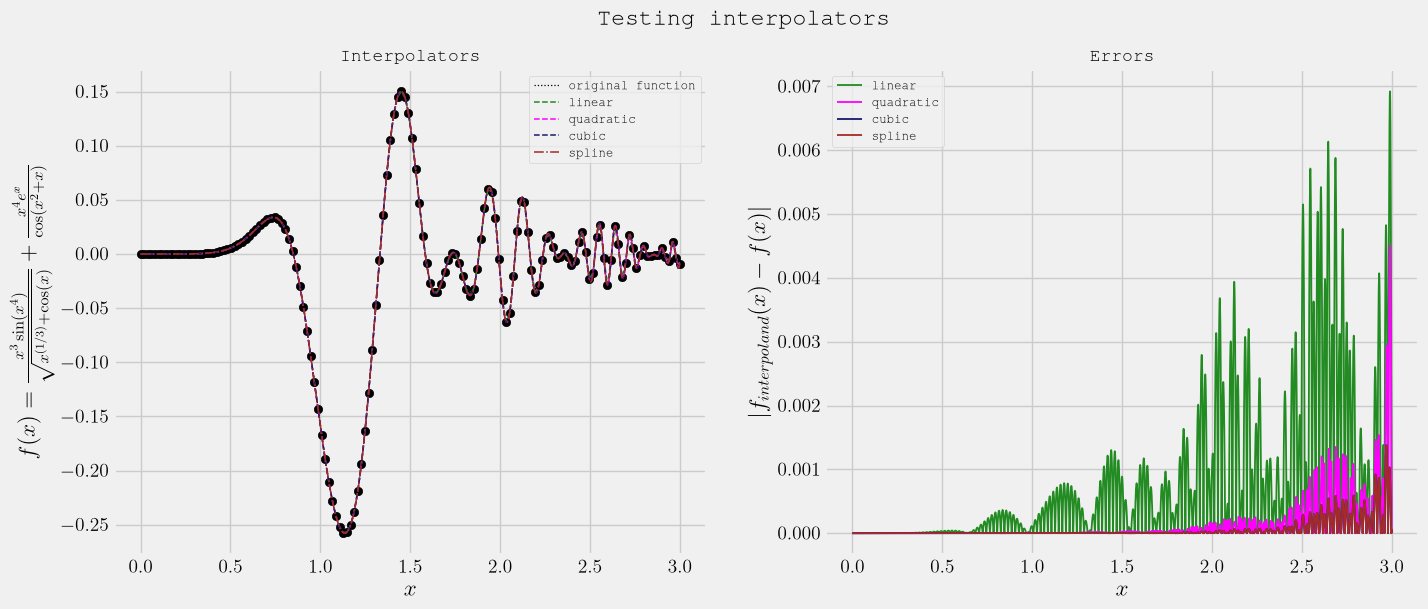

In [8]:
fig = plt.figure(figsize = (15,6))
fig.suptitle(r"Testing interpolators")

ax1 = plt.subplot(121)

ax1.set_title(r"Interpolators", fontsize = 13)
ax1.scatter(x, y, color = "black")
ax1.set_xlabel(r"$x$")
ax1.set_ylabel(r"$ f(x) = \frac{x^3 \sin(x^4)}{\sqrt{x^{(1/3)}+\cos(x)}} + \frac{x^4 e^x}{\cos(x^2 + x)}$")
ax1.plot(x1, my_func(x1), ls=":",linewidth = 0.9, label=r"original function", color = "black")
ax1.plot(x1, interpolands[0], ls="--",linewidth = 1.1, label=r"linear", color = "forestgreen")
ax1.plot(x1, interpolands[1], ls="--", linewidth = 1.1, label=r"quadratic", color = "magenta")
ax1.plot(x1, interpolands[2], ls="--", linewidth = 1.1, label=r"cubic", color = "midnightblue")
ax1.plot(x1, interpolands[3], ls="-.", linewidth = 1.1, label=r"spline", color = "brown")
ax1.legend(fontsize = 9)

ax2 = plt.subplot(122)

ax2.set_title(r"Errors", fontsize = 13)
ax2.set_xlabel(r"$x$")
ax2.set_ylabel(r"$|f_{interpoland}(x) - f(x)|$")
ax2.plot(x1, errors[0], ls="-",linewidth = 1.3, label=r"linear", color = "forestgreen")
ax2.plot(x1, errors[1], ls="-", linewidth = 1.3, label=r"quadratic", color = "magenta")
ax2.plot(x1, errors[2], ls="-", linewidth = 1.3, label=r"cubic", color = "midnightblue")
ax2.plot(x1, errors[3], ls="-", linewidth = 1.3, label=r"spline", color = "brown")
ax2.legend(fontsize = 9)

fig.savefig(f"out_dir/L04_interpolator_test_{N}_samples.pdf")

## Q5: Planetary orbits


\begin{align*}
\frac{dx}{dt} &= v_x \\
\frac{dy}{dt} &= v_y \\
\frac{dv_x}{dt} &= a_x = -\frac{GM_\star x}{r^3} \\
\frac{dv_y}{dt} &= a_y = -\frac{GM_\star y}{r^3}
\end{align*}

The distance of perihelion from the focus is:

$$r_p = a (1 - e)$$

where $a$ is the semi-major axis and $e$ is the eccentricity.  The perihelion velocity is all in the $y$ direction and is:

$$v_y = v_p = \sqrt{\frac{GM_\star}{a} \frac{1+e}{1-e}}$$

initial conditions:
  * $x(t=0) = r_p$
  * $y(t=0) = 0$
  * $v_x(t=0) = 0$
  * $v_y(t=0) = v_p$

$GM_\star = 4\pi^2$

Let's pretend we're tracking earth's orbit around the sun. The earth's trajectory around the sun is nearly circular, at a distance of 1 AU, but let's pretend for a while that it has a small measurable eccentricity

In [9]:
#eccentricity
e = 0.7
#semi major axis in AU 
a = 1.
#perihelion radius
rp = a*(1-e)

In [10]:
def rhs_func(t, X):
    xdot = X[2]
    ydot = X[3]
    r = np.sqrt(X[0]**2 + X[1]**2)
    vx = -(4*np.pi**2 / r**3) * X[0]
    vy = -(4*np.pi**2 / r**3) * X[1]
    return np.array([xdot, ydot, vx, vy])


def jacob(t, X):
    r = np.sqrt(X[0]**2 + X[1]**2)
    return np.array([
        [0., 0., 1., 0.],
        [0., 0., 0., 1.],
        [-4*np.pi**2 / r**3, 0., 0., 0.],
        [0., -4*np.pi**2 / r**3, 0., 0.],
    ])

# these functions will later be used to make the integrator "remember" the t and (x,y,vx,vy) quantities everytime
# x = rp and y = 0, so it trackes everytime the earth crosses the perihelion radius or everytime it crosses
# y = 0 which happens twice per orbit.

def perihelion_cross(t, X):
    return X[0] - rp


def half_orbits(t, X):
    return X[1]

In [11]:
#initial conditions
X0 = np.array([rp, 0., 0., np.sqrt((4*np.pi**2 / a) * ((1 + e) / (1 - e)))])

#final time of integration in years
tmax = 15

earth_trajectory = integrate.solve_ivp(
    rhs_func,
    (0.0, tmax),
    X0,
    dense_output=True,
    jac=jacob,
    events=(perihelion_cross, half_orbits),
)

#the minus one in the number of crosses is just to ignore the initial position
print(
    f"In {tmax:.1f} years, the earth orbits around the sun exactly {len(earth_trajectory.t_events[1]) // 2} times",
    f"and crosses the perihelion exactly {len(earth_trajectory.t_events[0]) - 1} times.",
)

In 15.0 years, the earth orbits around the sun exactly 17 times and crosses the perihelion exactly 31 times.


/Users/matildegarcia/macbox/lib/python3.11/site-packages/scipy/integrate/_ivp/ivp.py:623: UserWarning: The following arguments have no effect for a chosen solver: `jac`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


I really don't know what I could be doing wrong, but this is not even a trajectory, and nothing even changes when I change the eccentricity. Something is clearly off 

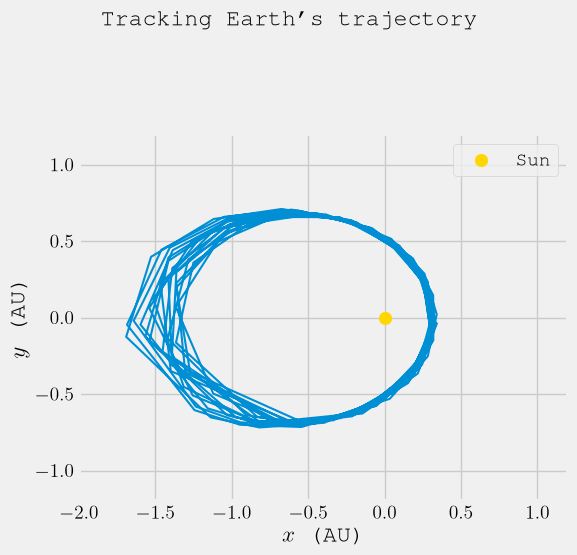

In [13]:
fig = plt.figure(figsize=(6, 6))
fig.suptitle(r"Tracking Earth's trajectory")
ax = fig.add_subplot(111)

sol = earth_trajectory.sol(earth_trajectory.t)
x_vals = sol[0]
y_vals = sol[1]

ax.plot(x_vals, y_vals, lw=1.5)
ax.scatter(0, 0, color="gold", s=80, label="Sun")
ax.set_xlabel(r"$x$ (AU)")
ax.set_ylabel(r"$y$ (AU)")
ax.set_aspect("equal")
ax.set_xlim(-2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.legend()
fig.tight_layout()